# Flow Matching for MNIST with Classifier-Free Guidance

This notebook provides a self-contained introduction to **flow matching** for image generation.
We implement a class-conditioned flow matching model using only PyTorch to generate MNIST digits
and demonstrate **Classifier-Free Guidance (CFG)** to control generation quality.

---

### What is Flow Matching?

Flow matching learns a **velocity field** $u_\theta(t, x_t)$ that defines an ODE transporting
samples from a simple prior (Gaussian noise) to the data distribution:

$$\frac{dx_t}{dt} = u_\theta(t, x_t), \quad x_0 \sim N(0, I), \quad t \in [0, 1]$$

We use the **conditional flow matching** objective with linear interpolation paths:

$$x_t = (1 - t)\, x_0 + t\, x_1, \quad u_t = x_1 - x_0$$

$$L = \mathbb{E}_{t,\, x_0,\, x_1} \left[ \| u_\theta(t, x_t, c) - u_t \|^2 \right]$$

### Classifier-Free Guidance (CFG)

During training, we randomly drop class labels with probability $p_\text{drop}$, replacing
them with a *null* token. At inference, we combine conditional and unconditional predictions:

$$\widetilde{u} = u_\theta(t, x_t, \varnothing) + w \cdot \bigl( u_\theta(t, x_t, c) - u_\theta(t, x_t, \varnothing) \bigr)$$

where $w$ is the **guidance scale**: $w = 1$ gives standard conditional generation,
$w > 1$ amplifies class conditioning at the cost of diversity.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import numpy as np
from tqdm.auto import tqdm
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Visual theme ──────────────────────────────────────────────────
BG_COLOR = "#F4E7D7"        # warm beige
TEXT_COLOR = "#3A2010"       # dark brown
ACCENT = "#D76829"          # warm orange
ACCENT2 = "#82381F"         # dark rust
GRID_COLOR = "#C4A882"      # muted tan

PALETTE = ["#82381F", "#D76829", "#E8A84C", "#A0522D", "#C07040",
           "#6B8E23", "#4682B4", "#8B668B", "#CD853F", "#708090"]

plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor": BG_COLOR,
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": TEXT_COLOR,
    "text.color": TEXT_COLOR,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    "axes.grid": False,
    "figure.dpi": 140,
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

# Custom brown-to-white colormap for digit images
DIGIT_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "warm_digits", ["#3A2010", "#82381F", "#D76829", "#F4E7D7"], N=256
)

Using device: cuda


## Configuration

In [ ]:
BATCH_SIZE = 256
LEARNING_RATE = 2e-4
NUM_EPOCHS = 5
NUM_CLASSES = 10
CFG_DROPOUT_PROB = 0.15          # probability of dropping class label during training
NULL_CLASS = NUM_CLASSES          # index 10 = unconditional / null token
ODE_STEPS = 25                  # number of Euler steps for ODE integration at inference

## Dataset

We load MNIST via HuggingFace `datasets` (more reliable than the torchvision mirrors)
and normalise pixel values to $[-1, 1]$.

In [ ]:
from datasets import load_dataset

# Load MNIST from HuggingFace Hub
hf_mnist = load_dataset("ylecun/mnist", split="train")


class MNISTDataset(Dataset):
    """Thin wrapper so we can use a standard DataLoader."""

    def __init__(self, hf_dataset):
        self.images = torch.stack([
            torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 127.5 - 1.0
            for img in hf_dataset["image"]
        ])
        self.labels = torch.tensor(hf_dataset["label"], dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


train_dataset = MNISTDataset(hf_mnist)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, drop_last=True, pin_memory=True,
)

print(f"Training samples: {len(train_dataset):,}")
print(f"Image shape:      {train_dataset[0][0].shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

mnist/train-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

mnist/test-00000-of-00001.parquet:   0%|          | 0.00/2.60M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Training samples: 60,000
Image shape:      torch.Size([1, 28, 28])


### Training Samples

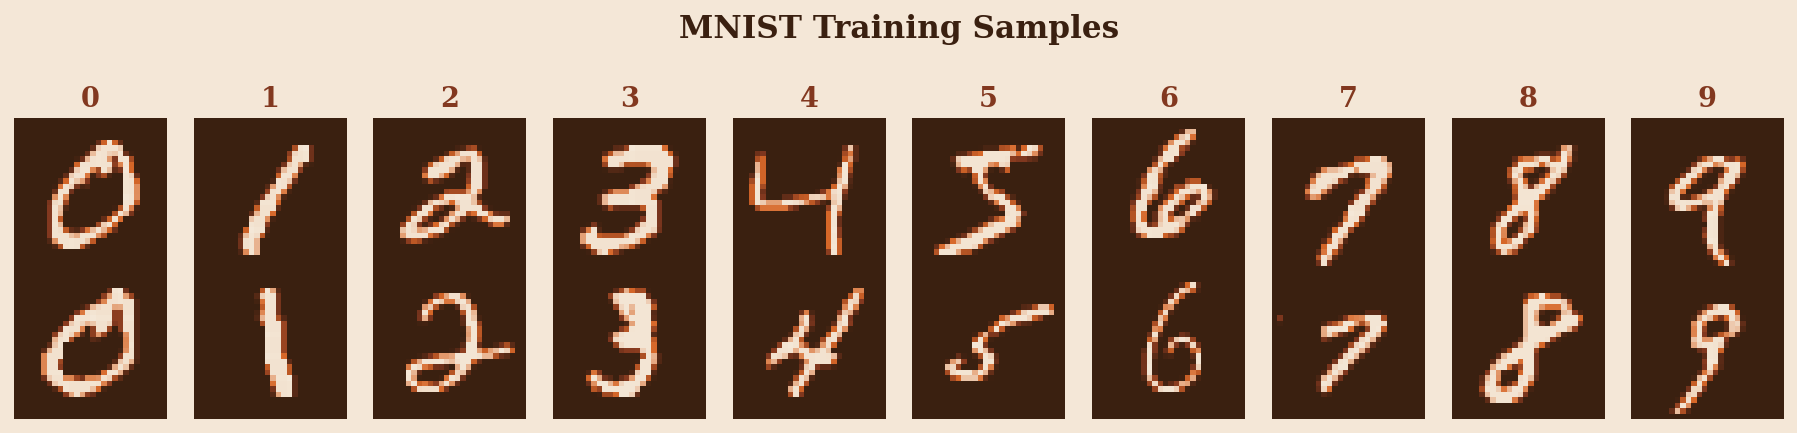

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(13, 3))
fig.patch.set_facecolor(BG_COLOR)

for digit in range(10):
    idxs = (train_dataset.labels == digit).nonzero(as_tuple=True)[0][:2]
    for row, idx in enumerate(idxs):
        img = train_dataset[idx.item()][0].squeeze()
        axes[row, digit].imshow(img, cmap=DIGIT_CMAP, vmin=-1, vmax=1)

        axes[row, digit].axis("off")
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=14, fontweight="bold",
                                       color=ACCENT2, pad=6)

fig.suptitle("MNIST Training Samples", fontsize=16, fontweight="bold",
             color=TEXT_COLOR, y=1.02)
plt.tight_layout()
plt.show()

## Model Architecture

We use a small **UNet** with:
- **Input convolution** to lift from 1 channel to 64 channels
- **Sinusoidal time embeddings** projected through an MLP
- **Learned class embeddings** (with a special *null* embedding for CFG)
- **Residual blocks** with GroupNorm and SiLU activations
- **Skip connections** between encoder and decoder

The model predicts the velocity field $u_\theta(t, x_t, c)$.


In [ ]:
class SinusoidalEmbedding(nn.Module):
    """Sinusoidal positional embedding for the time variable."""

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = torch.exp(-math.log(10_000) * torch.arange(half, device=t.device) / half)
        args = t[:, None] * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)


class ResBlock(nn.Module):
    """Residual block conditioned on a combined time + class embedding."""

    def __init__(self, in_ch: int, out_ch: int, emb_dim: int):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x: torch.Tensor, emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class FlowMatchingUNet(nn.Module):
    """
    Simple UNet for flow matching on 28x28 grayscale images.
    Architecture: 28x28 -> 14x14 -> 7x7 -> 14x14 -> 28x28
    """

    def __init__(self, in_ch: int = 1, base_ch: int = 64,
                 num_classes: int = 10, emb_dim: int = 128):
        super().__init__()

        self.time_emb = nn.Sequential(
            SinusoidalEmbedding(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        self.class_emb = nn.Embedding(num_classes + 1, emb_dim)

        # Lift 1-channel input to base_ch so all ResBlocks see GroupNorm-friendly sizes
        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        # Encoder
        self.enc1 = ResBlock(base_ch, base_ch, emb_dim)
        self.enc2 = ResBlock(base_ch, base_ch * 2, emb_dim)
        self.pool = nn.AvgPool2d(2)

        # Bottleneck
        self.mid1 = ResBlock(base_ch * 2, base_ch * 2, emb_dim)
        self.mid2 = ResBlock(base_ch * 2, base_ch * 2, emb_dim)

        # Decoder (input channels doubled due to skip connections)
        self.dec2 = ResBlock(base_ch * 4, base_ch, emb_dim)
        self.dec1 = ResBlock(base_ch * 2, base_ch, emb_dim)
        self.up = nn.Upsample(scale_factor=2, mode="nearest")

        # Output
        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, t: torch.Tensor, x: torch.Tensor,
                c: torch.Tensor) -> torch.Tensor:
        emb = self.time_emb(t) + self.class_emb(c)

        x = self.in_conv(x)                                     # (B, 64,  28, 28)

        # Encoder
        h1 = self.enc1(x, emb)                                  # (B, 64,  28, 28)
        h2 = self.enc2(self.pool(h1), emb)                      # (B, 128, 14, 14)

        # Bottleneck
        h = self.mid1(self.pool(h2), emb)                       # (B, 128, 7, 7)
        h = self.mid2(h, emb)                                    # (B, 128, 7, 7)

        # Decoder + skip connections
        h = self.dec2(torch.cat([self.up(h), h2], dim=1), emb)   # (B, 64,  14, 14)
        h = self.dec1(torch.cat([self.up(h), h1], dim=1), emb)   # (B, 64,  28, 28)

        return self.out_conv(F.silu(self.out_norm(h)))


model = FlowMatchingUNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Model parameters: 1,326,081


## Training

For each training step we:
1. Sample data $x_1$ and noise $x_0 \sim N(0, I)$
2. Sample time $t \sim \mathrm{Uniform}(0, 1)$
3. Interpolate: $x_t = (1-t)\, x_0 + t\, x_1$
4. Compute target velocity: $u_t = x_1 - x_0$
5. With probability $p_\text{drop}$, replace the class label with the null token
6. Minimise $\| u_\theta(t, x_t, c) - u_t \|^2$

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

losses = []
model.train()

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    for x_1, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1:02d}/{NUM_EPOCHS}", leave=False):
        x_1 = x_1.to(device)
        labels = labels.to(device)

        t = torch.rand(x_1.shape[0], device=device)
        x_0 = torch.randn_like(x_1)

        t_exp = t[:, None, None, None]
        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        u_t = x_1 - x_0

        # CFG: randomly drop class labels -> null token
        c = labels.clone()
        drop_mask = torch.rand(len(labels), device=device) < CFG_DROPOUT_PROB
        c[drop_mask] = NULL_CLASS

        v_pred = model(t, x_t, c)
        loss = F.mse_loss(v_pred, u_t)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:02d} | Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")

print("\nTraining complete!")

Epoch 01/5:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 01 | Loss: 0.3315 | LR: 1.81e-04


Epoch 02/5:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 03/5:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 04/5:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 05/5:   0%|          | 0/234 [00:00<?, ?it/s]

Epoch 05 | Loss: 0.1849 | LR: 0.00e+00

Training complete!


### Training Loss

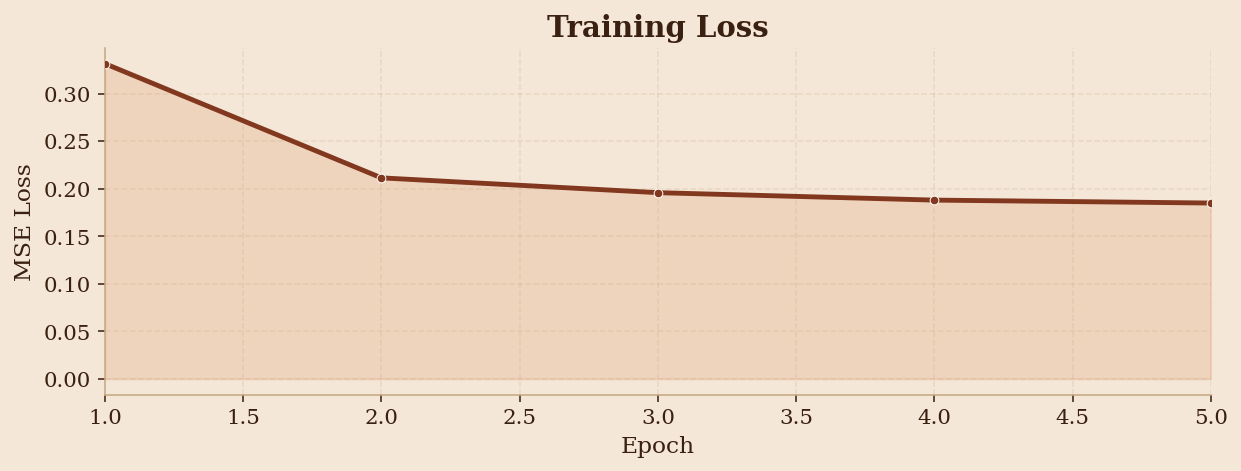

In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.5))

epochs = range(1, len(losses) + 1)
ax.fill_between(epochs, losses, alpha=0.15, color=ACCENT)
ax.plot(epochs, losses, color=ACCENT2, linewidth=2.5, zorder=5)
ax.scatter(epochs, losses, color=ACCENT2, s=20, zorder=6, edgecolors="white", linewidths=0.5)

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("MSE Loss", fontsize=12)
ax.set_title("Training Loss", fontsize=15, fontweight="bold", color=TEXT_COLOR)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["bottom", "left"]].set_color(GRID_COLOR)
ax.grid(True, alpha=0.25, color=GRID_COLOR, linestyle="--")
ax.set_xlim(1, len(losses))

plt.tight_layout()
plt.show()

## Sampling with Classifier-Free Guidance

We solve the ODE from $t = 0$ to $t = 1$ using the **Euler method**:

$$x_{t + \Delta t} = x_t + \Delta t \cdot \widetilde{u}_\theta(t, x_t, c)$$

With CFG, the guided velocity is:

$$\widetilde{u} =u_\theta(t, x_t, \varnothing) + \; w \cdot \left(u_\theta(t, x_t, c) - u_\theta(t, x_t, \varnothing)\right)$$

| Guidance scale $w$ | Behaviour |
|---|---|
| $w = 0$ | Purely unconditional (ignores class) |
| $w = 1$ | Standard conditional (no guidance) |
| $w > 1$ | Amplified conditioning, sharper but less diverse |

In [ ]:
@torch.no_grad()
def sample(model, n_per_class, guidance_scale=2.0, n_steps=ODE_STEPS,
           return_trajectory=False, seed=None):
    """Generate samples for all 10 digit classes using Euler integration + CFG."""
    if seed is not None:
        torch.manual_seed(seed)

    model.eval()
    n_total = n_per_class * NUM_CLASSES

    x = torch.randn(n_total, 1, 28, 28, device=device)
    labels = torch.arange(NUM_CLASSES, device=device).repeat_interleave(n_per_class)
    null_labels = torch.full_like(labels, NULL_CLASS)

    traj_steps = set(range(0, n_steps + 1, max(1, n_steps // 10)))
    trajectory = [x.cpu()] if return_trajectory else None

    dt = 1.0 / n_steps
    for i in range(n_steps):
        t = torch.full((n_total,), i * dt, device=device)

        if guidance_scale == 0.0:
            v = model(t, x, null_labels)
        elif guidance_scale == 1.0:
            v = model(t, x, labels)
        else:
            v_cond = model(t, x, labels)
            v_uncond = model(t, x, null_labels)
            v = v_uncond + guidance_scale * (v_cond - v_uncond)

        x = x + v * dt

        if return_trajectory and (i + 1) in traj_steps:
            trajectory.append(x.cpu())

    x = x.clamp(-1, 1)
    if return_trajectory:
        return x, trajectory
    return x

## Generated Samples

Eight samples per digit class with guidance scale $w = 2.0$:

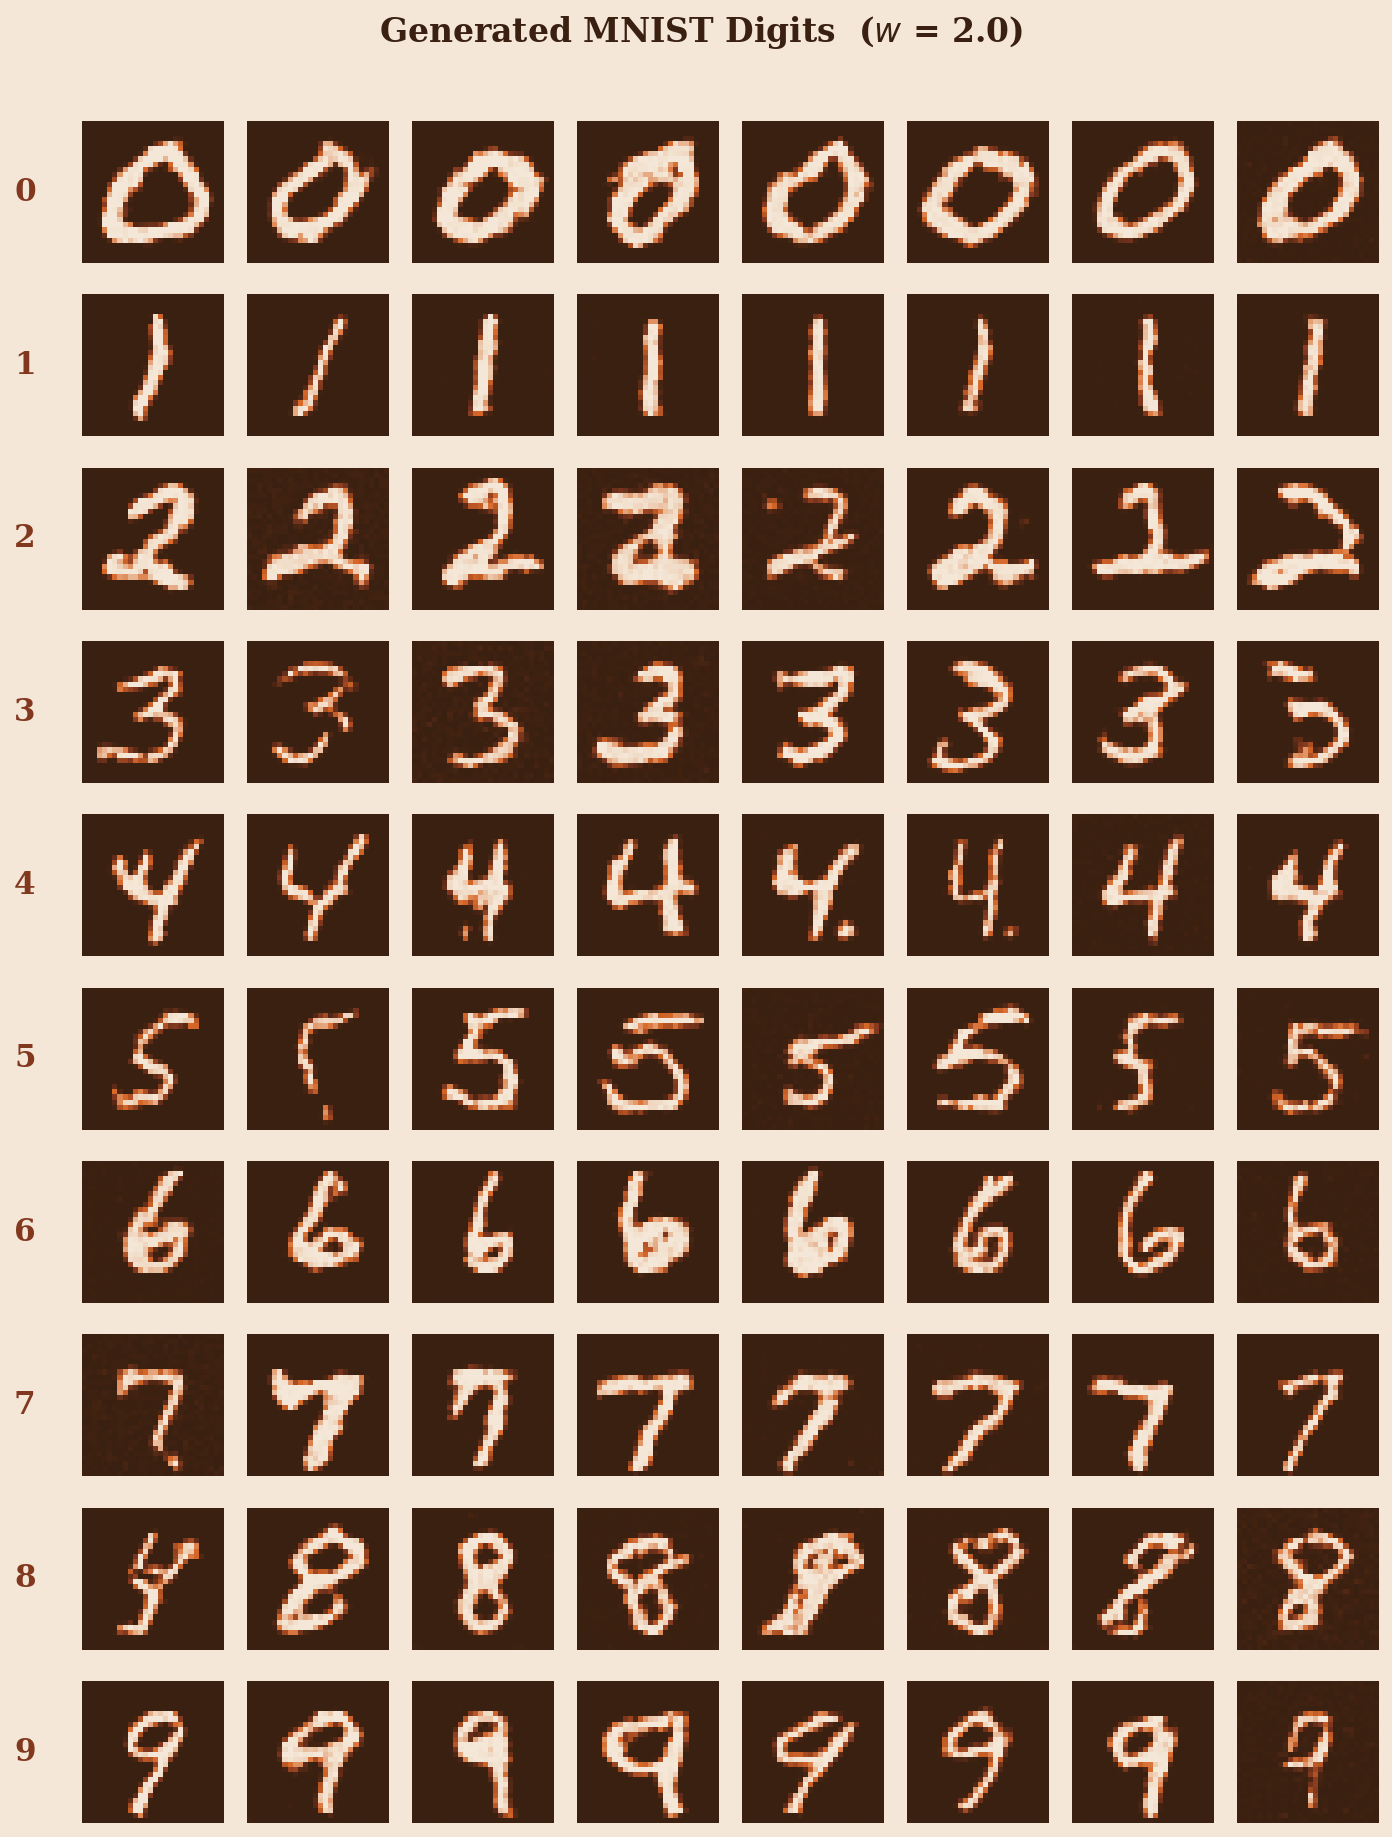

In [ ]:
samples = sample(model, n_per_class=8, guidance_scale=2.0, seed=42)

fig, axes = plt.subplots(NUM_CLASSES, 8, figsize=(10, 13))
fig.patch.set_facecolor(BG_COLOR)

for digit in range(NUM_CLASSES):
    for j in range(8):
        img = samples[digit * 8 + j, 0].cpu()
        axes[digit, j].imshow(img, cmap=DIGIT_CMAP, vmin=-1, vmax=1)
        axes[digit, j].axis("off")

    axes[digit, 0].text(
        -0.4, 0.5, str(digit), transform=axes[digit, 0].transAxes,
        fontsize=16, fontweight="bold", color=ACCENT2,
        ha="center", va="center",
    )

fig.suptitle("Generated MNIST Digits  ($w$ = 2.0)", fontsize=17, fontweight="bold",
             color=TEXT_COLOR, y=1.01)
plt.tight_layout()
plt.show()

## Effect of Guidance Scale

We generate the **same digits from the same initial noise** at different guidance scales
to isolate the effect of $w$. Higher guidance produces sharper, more prototypical digits
but reduces sample diversity.

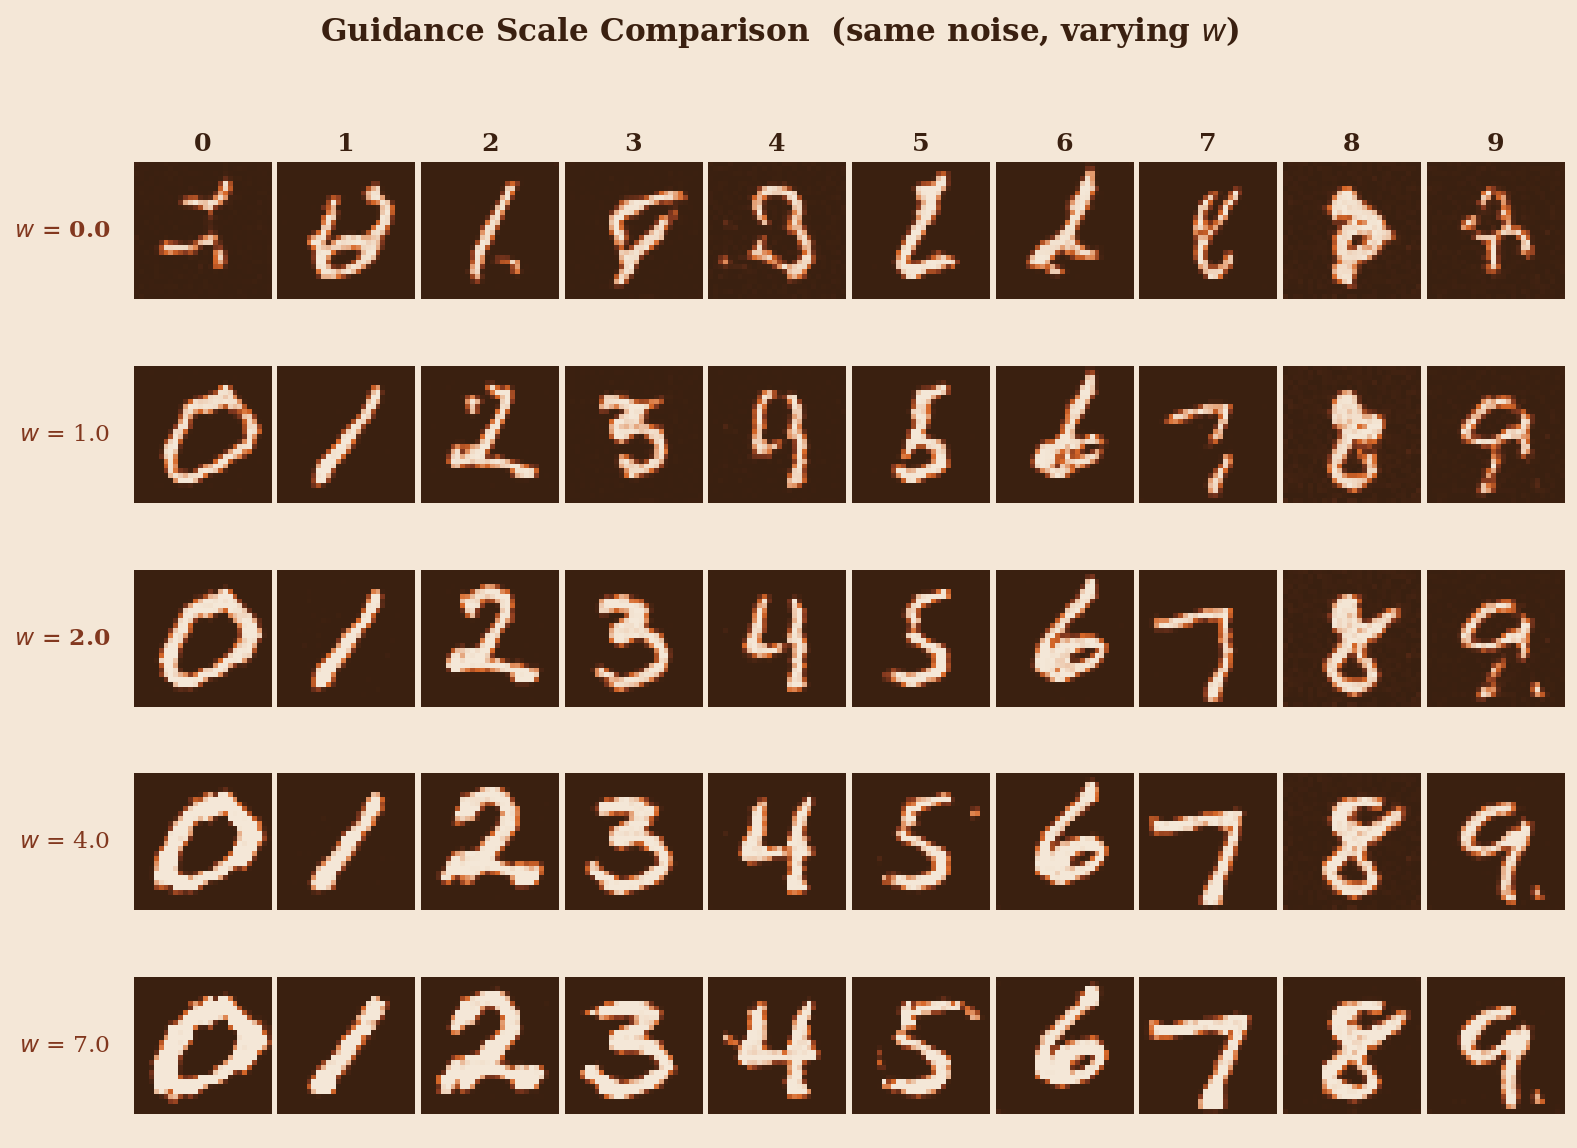

In [ ]:
guidance_scales = [0.0, 1.0, 2.0, 4.0, 7.0]

all_samples = {}
for w in guidance_scales:
    all_samples[w] = sample(model, n_per_class=1, guidance_scale=w, seed=123)

fig = plt.figure(figsize=(14, len(guidance_scales) * 1.6 + 1.2))
fig.patch.set_facecolor(BG_COLOR)

gs = GridSpec(len(guidance_scales), NUM_CLASSES + 1,
              width_ratios=[0.6] + [1] * NUM_CLASSES,
              wspace=0.05, hspace=0.15)

for row, w in enumerate(guidance_scales):
    # Label column
    ax_label = fig.add_subplot(gs[row, 0])
    ax_label.set_facecolor(BG_COLOR)
    ax_label.axis("off")
    style = "bold" if w in (0.0, 2.0) else "normal"
    ax_label.text(0.8, 0.5, f"$w$ = {w:.1f}", transform=ax_label.transAxes,
                  fontsize=12, fontweight=style, color=ACCENT2,
                  ha="right", va="center")

    for digit in range(NUM_CLASSES):
        ax = fig.add_subplot(gs[row, digit + 1])
        img = all_samples[w][digit, 0].cpu()
        ax.imshow(img, cmap=DIGIT_CMAP, vmin=-1, vmax=1)
        ax.axis("off")
        if row == 0:
            ax.set_title(str(digit), fontsize=13, fontweight="bold",
                         color=TEXT_COLOR, pad=6)

fig.suptitle("Guidance Scale Comparison  (same noise, varying $w$)",
             fontsize=16, fontweight="bold", color=TEXT_COLOR, y=0.98)
plt.show()

### Diversity vs. Quality Trade-off

For a few selected digits, we show **multiple samples** at each guidance scale.
Notice how higher $w$ makes digits more uniform (less diverse) but crisper.

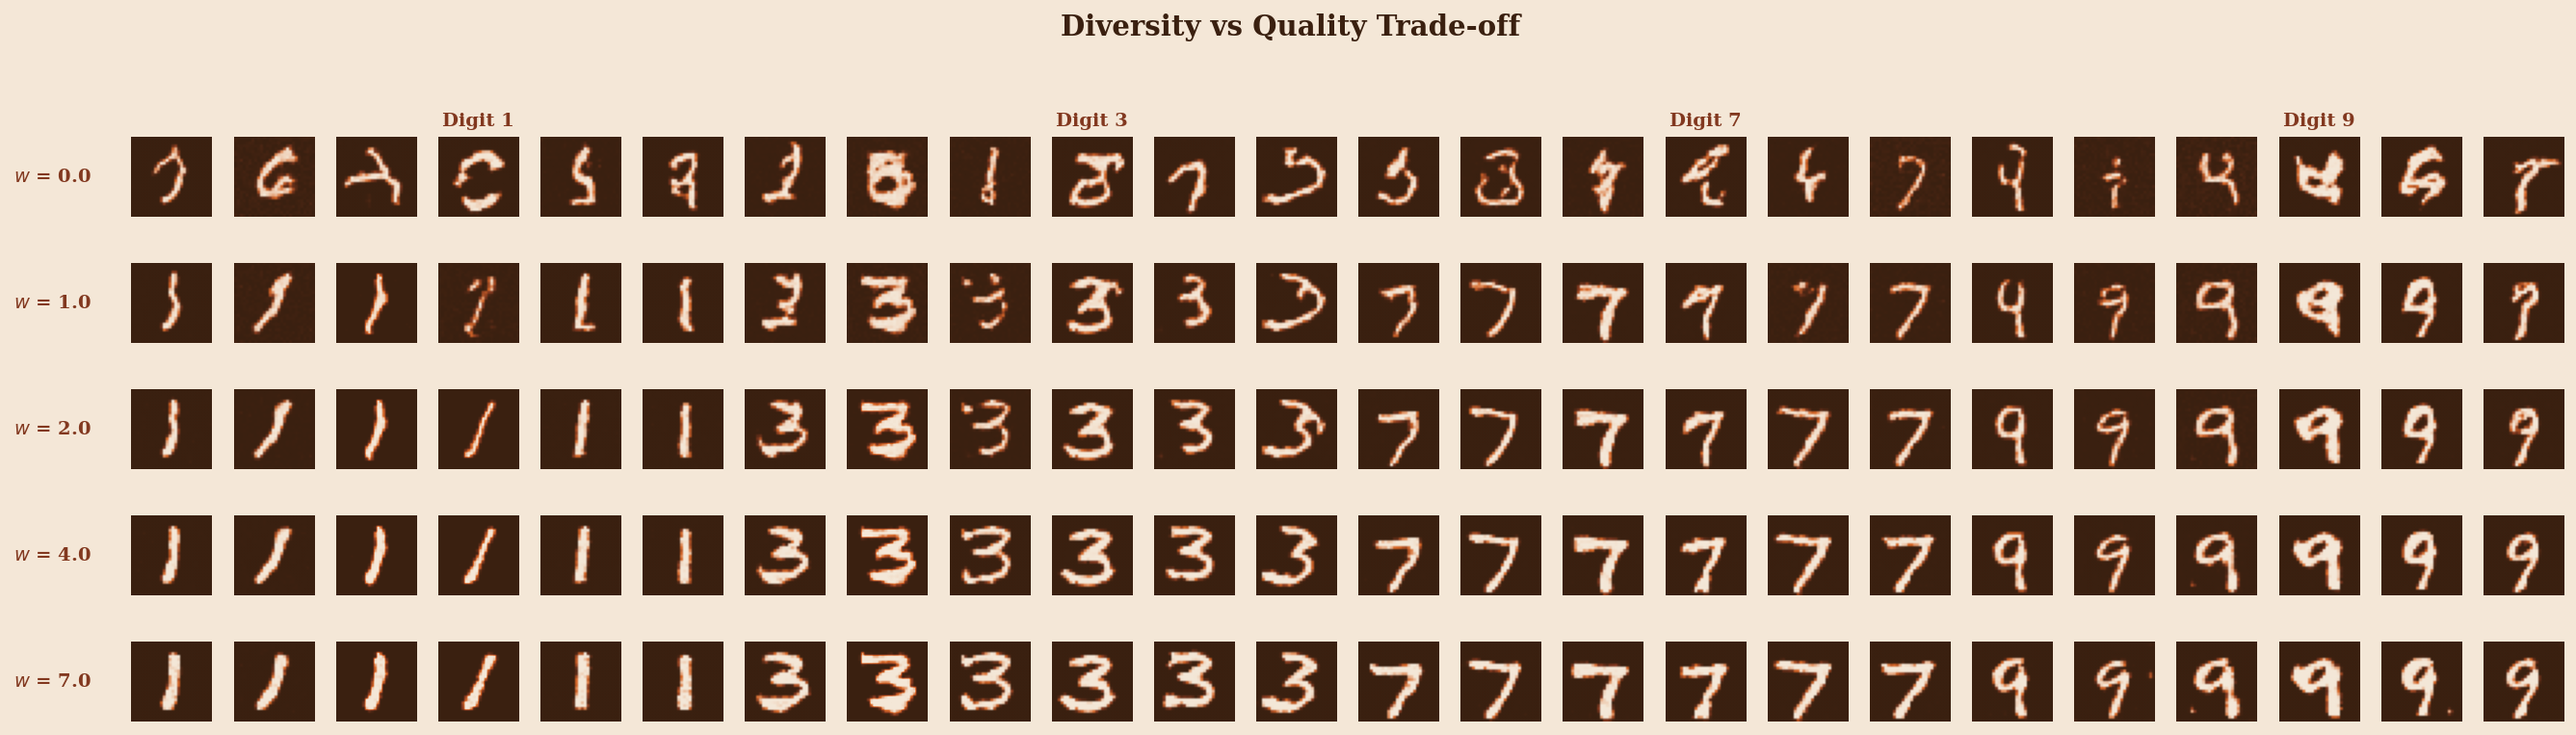

In [ ]:
selected_digits = [1, 3, 7, 9]
n_show = 6

fig, axes = plt.subplots(
    len(guidance_scales), len(selected_digits) * n_show,
    figsize=(len(selected_digits) * n_show * 0.8, len(guidance_scales) * 1.1),
)
fig.patch.set_facecolor(BG_COLOR)

for row, w in enumerate(guidance_scales):
    s = sample(model, n_per_class=n_show, guidance_scale=w, seed=42)
    col = 0
    for d_idx, digit in enumerate(selected_digits):
        for j in range(n_show):
            img = s[digit * n_show + j, 0].cpu()
            axes[row, col].imshow(img, cmap=DIGIT_CMAP, vmin=-1, vmax=1)
            axes[row, col].axis("off")
            # Group header for first row
            if row == 0 and j == n_show // 2:
                axes[row, col].set_title(
                    f"Digit {digit}", fontsize=10, fontweight="bold",
                    color=ACCENT2,
                )
            col += 1
    axes[row, 0].text(
        -0.5, 0.5, f"$w$ = {w:.1f}", transform=axes[row, 0].transAxes,
        fontsize=10, fontweight="bold", color=ACCENT2,
        ha="right", va="center",
    )

fig.suptitle("Diversity vs Quality Trade-off",
             fontsize=15, fontweight="bold", color=TEXT_COLOR, y=1.02)
plt.tight_layout()
plt.show()

## Generation Process

Visualising how noise transforms into digits across the flow trajectory ($t = 0 \to 1$).
Each column is a snapshot at a different time step.

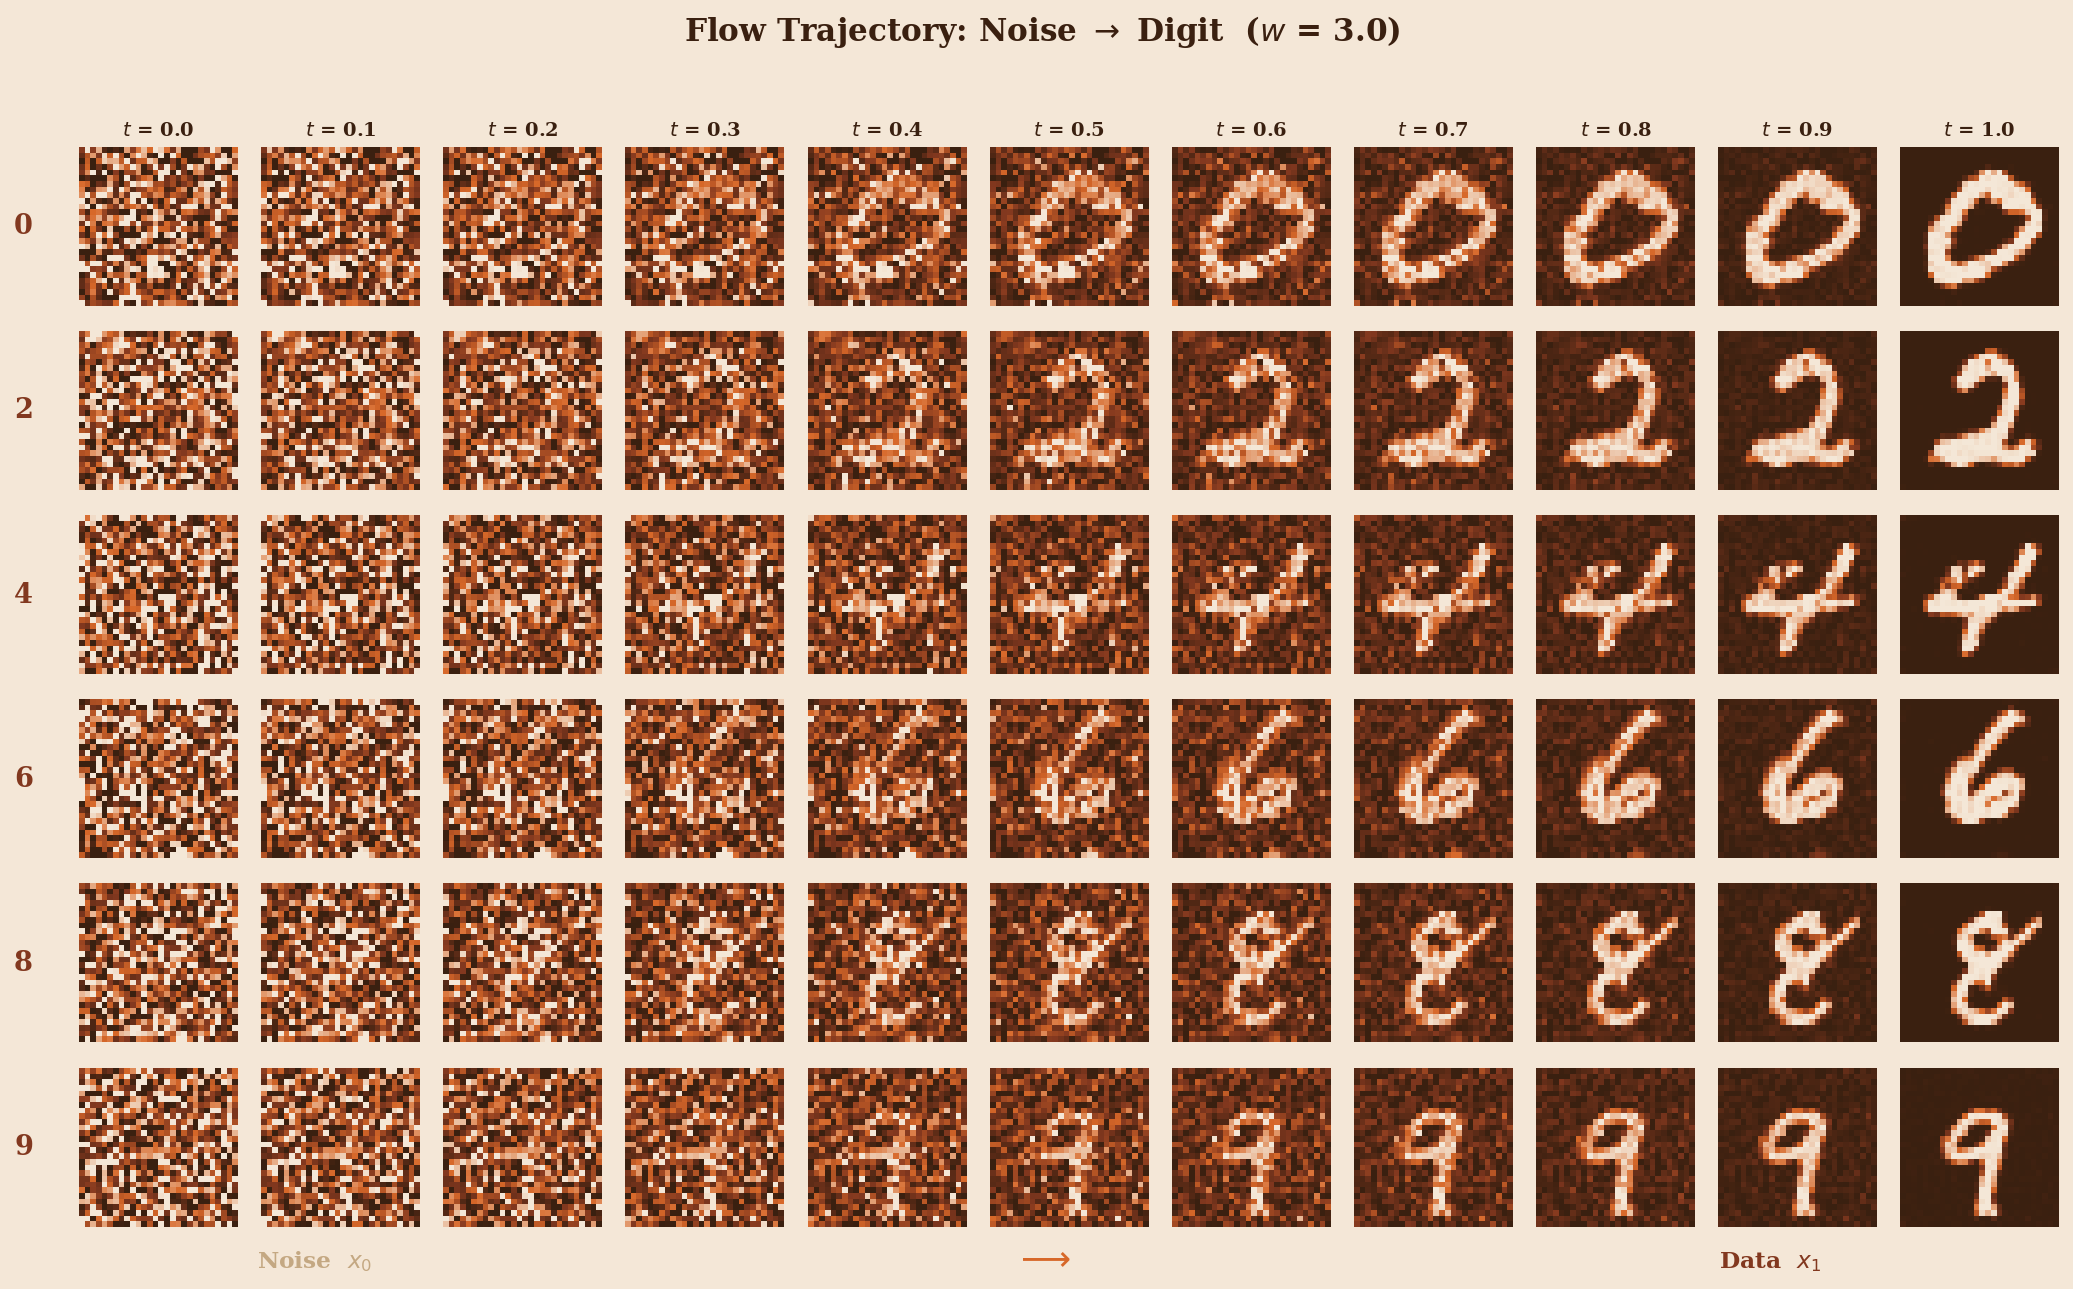

In [ ]:
show_digits = [0, 2, 4, 6, 8, 9]
_, trajectory = sample(
    model, n_per_class=1, guidance_scale=3.0,
    n_steps=100, return_trajectory=True, seed=7,
)

n_snaps = len(trajectory)
fig, axes = plt.subplots(len(show_digits), n_snaps,
                         figsize=(n_snaps * 1.35, len(show_digits) * 1.45))
fig.patch.set_facecolor(BG_COLOR)

time_labels = [f"$t$ = {i / 10:.1f}" for i in range(n_snaps)]

for row, digit in enumerate(show_digits):
    for col, snap in enumerate(trajectory):
        img = snap[digit, 0]
        axes[row, col].imshow(img, cmap=DIGIT_CMAP, vmin=-1, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(time_labels[col], fontsize=10, color=TEXT_COLOR)
    axes[row, 0].text(
        -0.35, 0.5, str(digit), transform=axes[row, 0].transAxes,
        fontsize=14, fontweight="bold", color=ACCENT2,
        ha="center", va="center",
    )

# Add a flow arrow below
fig.text(0.15, -0.01, "Noise  $x_0$", fontsize=12, color=GRID_COLOR,
         fontweight="bold", ha="center")
fig.text(0.5, -0.01, r"$\longrightarrow$", fontsize=18, color=ACCENT,
         ha="center", fontweight="bold")
fig.text(0.85, -0.01, "Data  $x_1$", fontsize=12, color=ACCENT2,
         fontweight="bold", ha="center")

fig.suptitle("Flow Trajectory: Noise $\\to$ Digit  ($w$ = 3.0)",
             fontsize=16, fontweight="bold", color=TEXT_COLOR, y=1.02)
plt.tight_layout()
plt.show()

## Interpolation in Noise Space

We linearly interpolate between two noise vectors and generate each intermediate point,
showing how the model smoothly transitions between outputs.

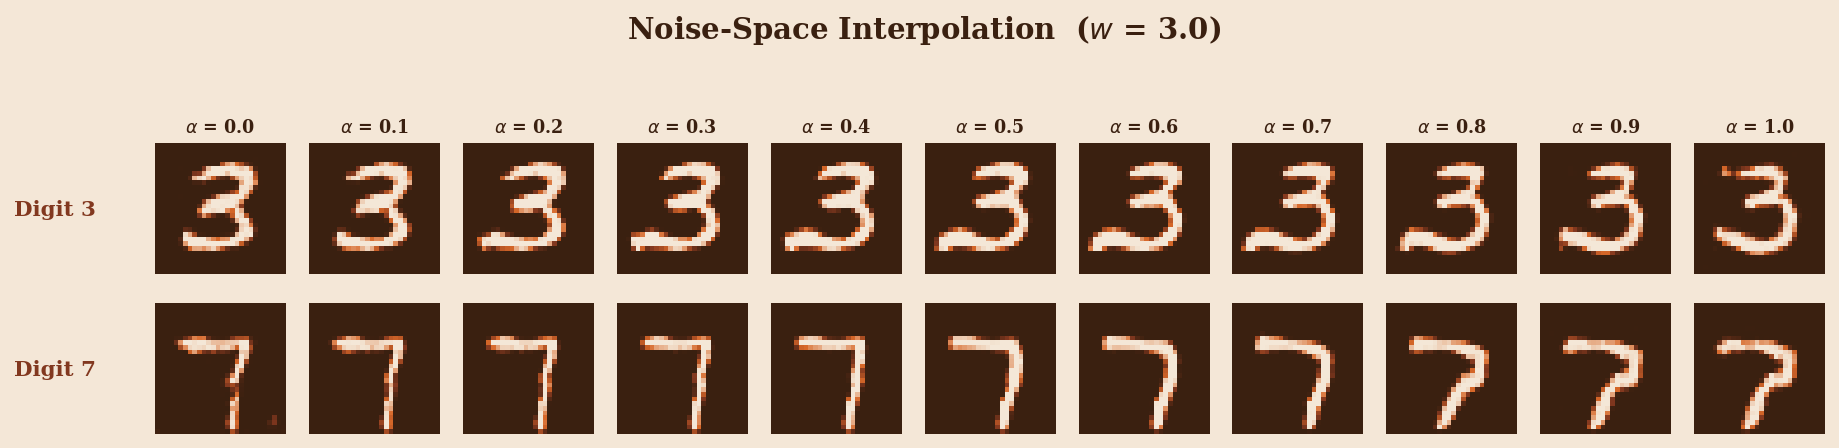

In [ ]:
@torch.no_grad()
def sample_from_noise(model, x_init, labels, guidance_scale=3.0, n_steps=ODE_STEPS):
    """Run the ODE from given initial noise."""
    model.eval()
    x = x_init.clone()
    null_labels = torch.full_like(labels, NULL_CLASS)
    dt = 1.0 / n_steps
    for i in range(n_steps):
        t = torch.full((x.shape[0],), i * dt, device=device)
        v_cond = model(t, x, labels)
        v_uncond = model(t, x, null_labels)
        v = v_uncond + guidance_scale * (v_cond - v_uncond)
        x = x + v * dt
    return x.clamp(-1, 1)


torch.manual_seed(2024)
z_a = torch.randn(1, 1, 28, 28, device=device)
z_b = torch.randn(1, 1, 28, 28, device=device)

n_interp = 11
alphas = torch.linspace(0, 1, n_interp)

interp_digits = [3, 7]

fig, axes = plt.subplots(len(interp_digits), n_interp,
                         figsize=(n_interp * 1.2, len(interp_digits) * 1.6))
fig.patch.set_facecolor(BG_COLOR)

for row, digit in enumerate(interp_digits):
    label = torch.tensor([digit], device=device)
    for col, alpha in enumerate(alphas):
        z = (1 - alpha) * z_a + alpha * z_b
        img = sample_from_noise(model, z, label, guidance_scale=3.0)
        axes[row, col].imshow(img[0, 0].cpu(), cmap=DIGIT_CMAP, vmin=-1, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"$\\alpha$ = {alpha:.1f}", fontsize=9, color=TEXT_COLOR)
    axes[row, 0].text(
        -0.45, 0.5, f"Digit {digit}", transform=axes[row, 0].transAxes,
        fontsize=11, fontweight="bold", color=ACCENT2,
        ha="right", va="center",
    )

fig.suptitle("Noise-Space Interpolation  ($w$ = 3.0)",
             fontsize=15, fontweight="bold", color=TEXT_COLOR, y=1.05)
plt.tight_layout()
plt.show()

## Effect of ODE Steps

A key advantage of flow matching is that generation only requires solving an ODE
and the number of Euler steps directly controls the speed/quality trade-off.
Fewer steps mean faster generation but coarser integration; more steps give
the solver time to follow the velocity field accurately.

We generate the **same digits from the same noise** with varying step counts
to visualise the degradation.

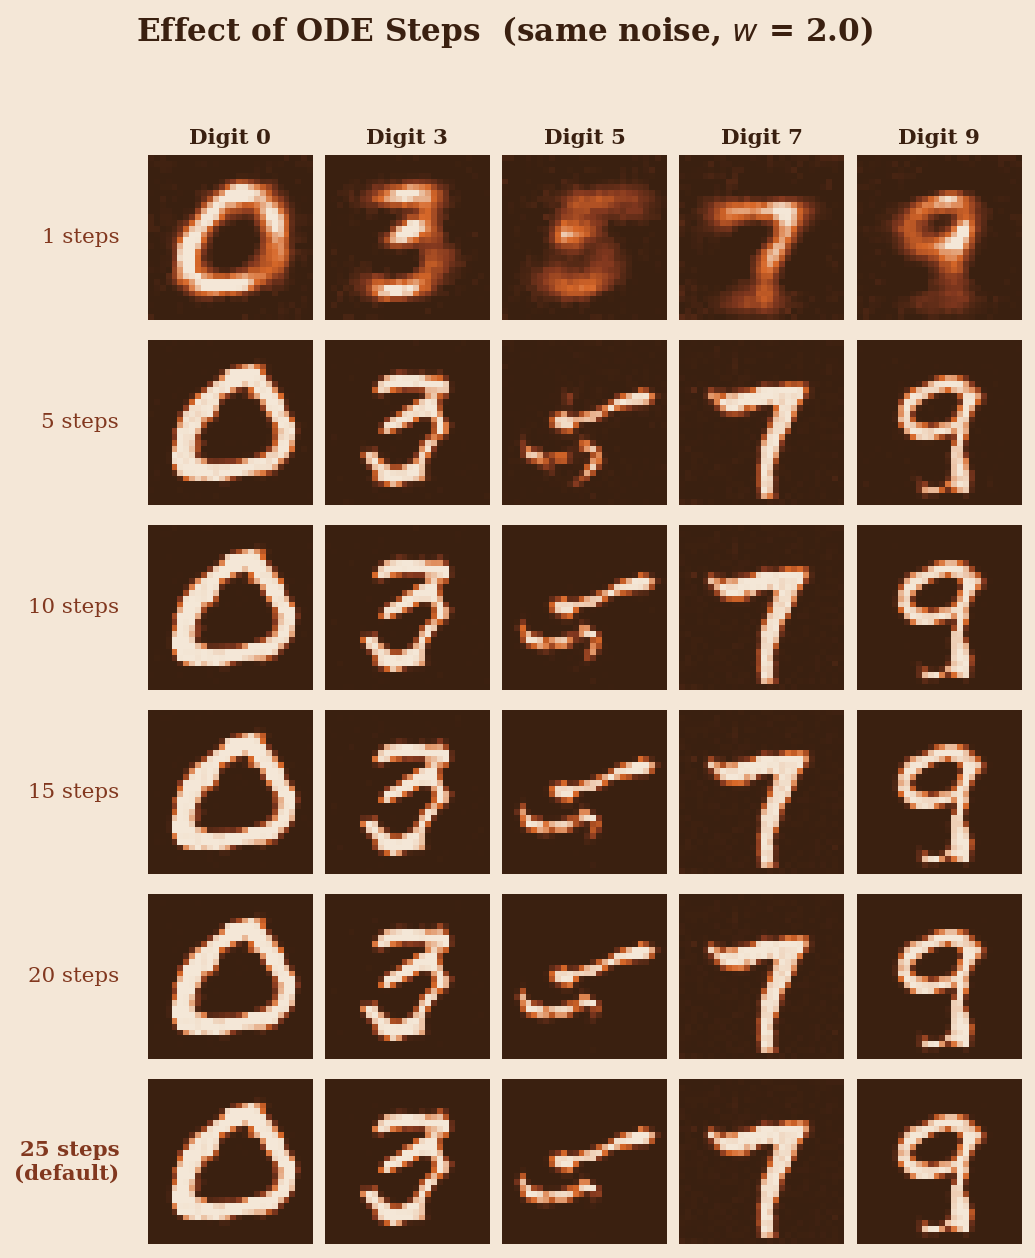

In [ ]:
step_counts = [1, 5, 10, 15, 20, ODE_STEPS]
show_digits_steps = [0, 3, 5, 7, 9]

step_samples = {}
for ns in step_counts:
    step_samples[ns] = sample(model, n_per_class=1, guidance_scale=2.0, n_steps=ns, seed=42)

fig = plt.figure(figsize=(len(show_digits_steps) * 1.55 + 1.5, len(step_counts) * 1.55 + 0.8))
fig.patch.set_facecolor(BG_COLOR)

gs = GridSpec(len(step_counts), len(show_digits_steps) + 1,
              width_ratios=[0.7] + [1] * len(show_digits_steps),
              wspace=0.06, hspace=0.12)

for row, ns in enumerate(step_counts):
    # Label column
    ax_label = fig.add_subplot(gs[row, 0])
    ax_label.set_facecolor(BG_COLOR)
    ax_label.axis("off")
    bold = "bold" if ns == ODE_STEPS else "normal"
    label_text = f"{ns} steps" if ns != ODE_STEPS else f"{ns} steps\n(default)"
    ax_label.text(0.85, 0.5, label_text, transform=ax_label.transAxes,
                  fontsize=11, fontweight=bold, color=ACCENT2,
                  ha="right", va="center")

    for col, digit in enumerate(show_digits_steps):
        ax = fig.add_subplot(gs[row, col + 1])
        img = step_samples[ns][digit, 0].cpu()
        ax.imshow(img, cmap=DIGIT_CMAP, vmin=-1, vmax=1)
        ax.axis("off")
        if row == 0:
            ax.set_title(f"Digit {digit}", fontsize=11, fontweight="bold",
                         color=TEXT_COLOR, pad=6)

fig.suptitle("Effect of ODE Steps  (same noise, $w$ = 2.0)",
             fontsize=16, fontweight="bold", color=TEXT_COLOR, y=0.98)
plt.show()

## Inpainting with Flow Matching

A powerful application of flow matching is **inpainting**: reconstructing missing
parts of an image while keeping the observed region intact. Since the flow defines
a transport from noise $x_0$ to data $x_1$, we can constrain the ODE so that
*known* pixels follow the correct interpolation path while *unknown* pixels are
freely generated by the model.

**Algorithm (replacement method):**

1. Given a real image $x_1^\text{real}$ and a binary mask $M$ ($M = 1$ for known pixels),
   sample initial noise $x_0 \sim N(0, I)$.
2. At each Euler step from $t$ to $t + \Delta t$:
   - Compute the guided velocity $\widetilde{u}_\theta(t, x_t, c)$ over the **full** image
   - Update: $x_{t+\Delta t} = x_t + \Delta t \cdot \widetilde{u}$
   - **Replace** known pixels with their reference value on the interpolation path:
     $$x_{t'}^{\text{ref}} = (1 - t') x_0 + t'x_1^{\text{real}}, \quad t' = t + \Delta t$$
     $$x_{t'} \leftarrow M \cdot x_{t'}^{\text{ref}} + (1 - M) \cdot x_{t'}$$

This ensures the known region stays consistent while the model hallucinates the
masked region conditioned on the surrounding context.

We demonstrate this by **masking the upper half** of real MNIST digits and
letting the flow model reconstruct it.

In [ ]:
@torch.no_grad()
def inpaint(model, x_real, mask, labels, noise=None,
            guidance_scale=3.0, n_steps=50):
    """Inpaint masked regions using the replacement method.

    Args:
        x_real:  Real images (B, 1, 28, 28) in [-1, 1].
        mask:    Binary mask (B, 1, 28, 28). 1 = known, 0 = to inpaint.
        labels:  Class labels (B,).
        noise:   Optional initial noise; sampled if None.
    """
    model.eval()
    B = x_real.shape[0]

    x_0 = noise if noise is not None else torch.randn_like(x_real)
    x = x_0.clone()
    null_labels = torch.full_like(labels, NULL_CLASS)

    dt = 1.0 / n_steps
    for i in range(n_steps):
        t_val = i * dt
        t = torch.full((B,), t_val, device=device)

        # CFG velocity
        v_cond = model(t, x, labels)
        v_uncond = model(t, x, null_labels)
        v = v_uncond + guidance_scale * (v_cond - v_uncond)

        # Euler step
        x = x + v * dt

        # Replace known pixels with their interpolation-path value
        t_next = (i + 1) * dt
        x_ref = (1 - t_next) * x_0 + t_next * x_real
        x = mask * x_ref + (1 - mask) * x

    return x.clamp(-1, 1)


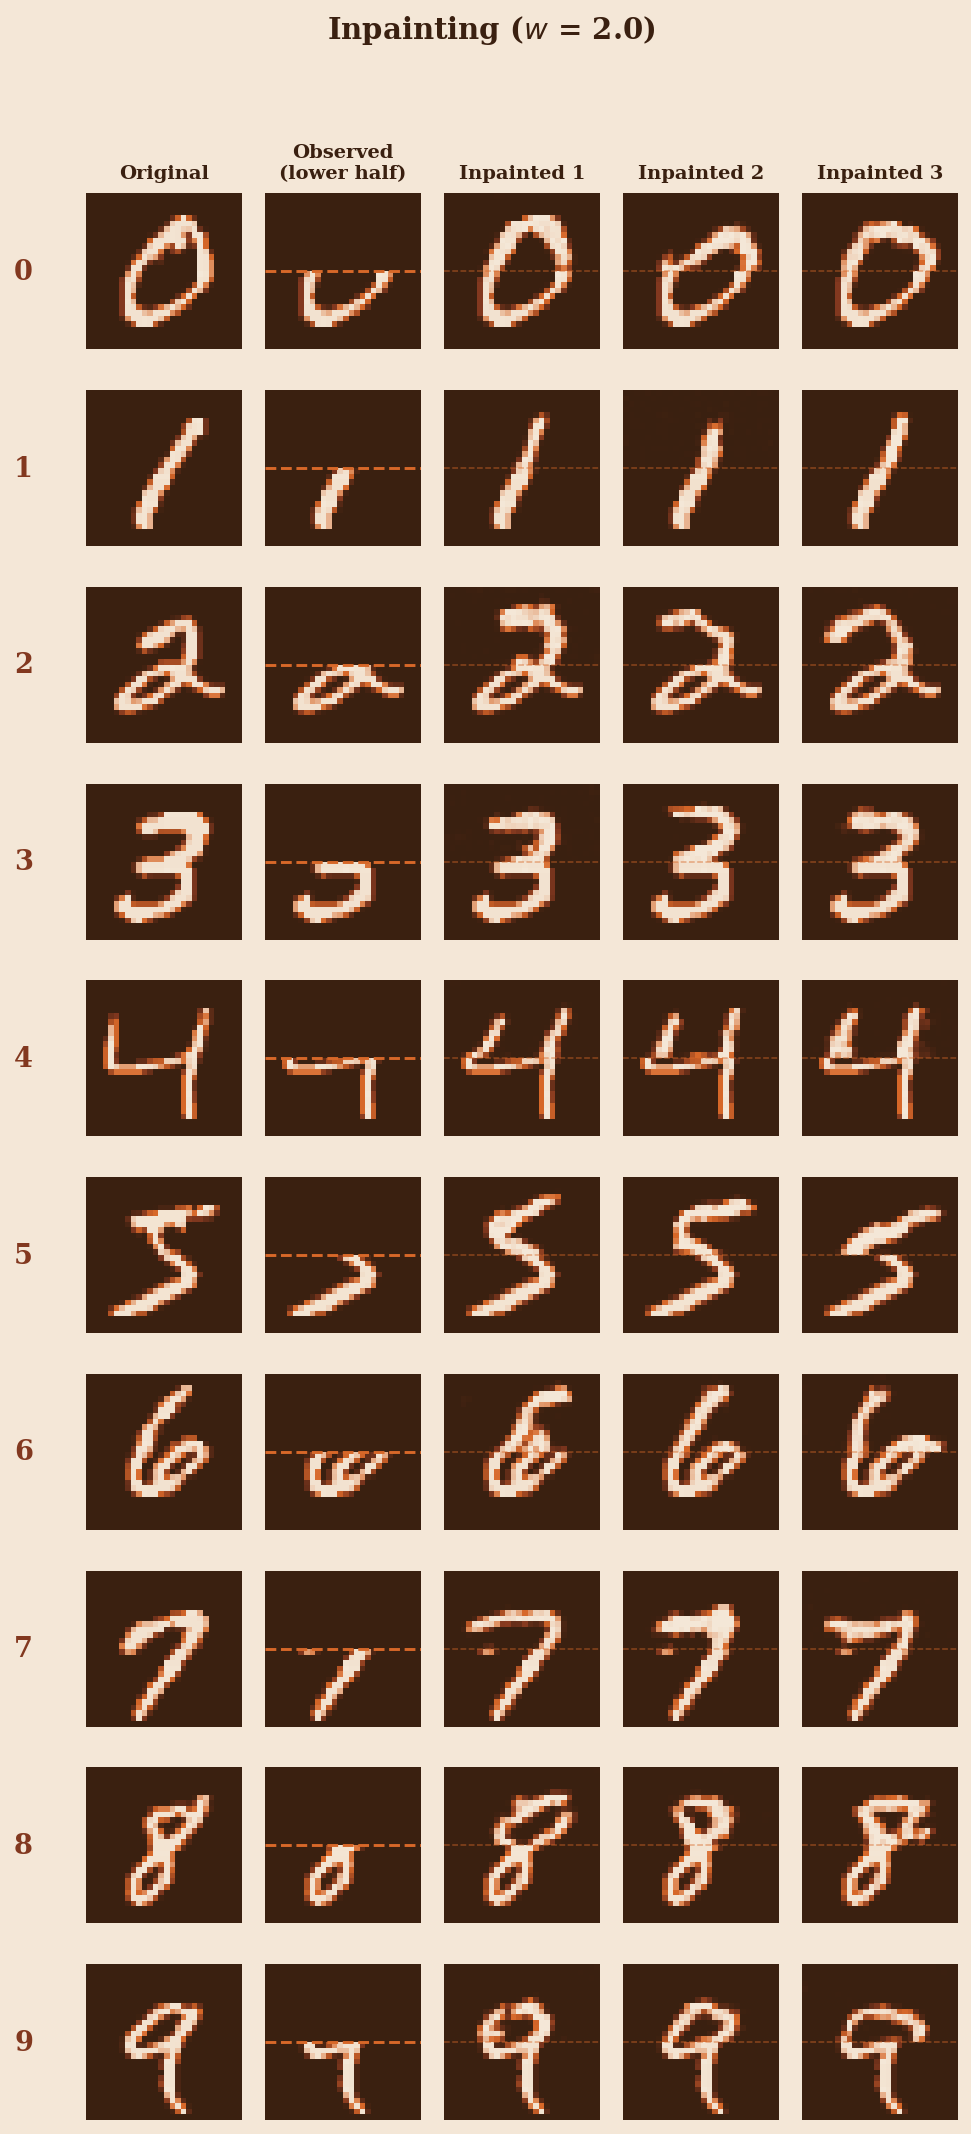

In [ ]:
show_digits_inp = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n_resample = 3  # number of different inpaintings per digit

real_imgs, real_labels = [], []
for digit in show_digits_inp:
    idx = (train_dataset.labels == digit).nonzero(as_tuple=True)[0][0]
    img, lab = train_dataset[idx.item()]
    real_imgs.append(img)
    real_labels.append(lab)

real_imgs = torch.stack(real_imgs).to(device)      # (10, 1, 28, 28)
real_labels = torch.tensor(real_labels, device=device)

# Mask: keep the lower half (rows 14-27), inpaint the upper half (rows 0-13)
mask = torch.zeros(1, 1, 28, 28, device=device)
mask[:, :, 14:, :] = 1.0  # 1 = known (lower half)

real_rep = real_imgs.repeat(n_resample, 1, 1, 1)      # (30, 1, 28, 28)
labels_rep = real_labels.repeat(n_resample)         # (30,)
mask_rep = mask.expand_as(real_rep)

torch.manual_seed(2024)
inpainted = inpaint(model, real_rep, mask_rep, labels_rep,
                    guidance_scale=2.0, n_steps=50)

n_digits = len(show_digits_inp)
n_rows = n_digits
n_cols = 2 + n_resample

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.4, n_rows * 1.5))
fig.patch.set_facecolor(BG_COLOR)

col_titles = ["Original", "Observed\n(lower half)"] + [
    f"Inpainted {k+1}" for k in range(n_resample)]

for row, digit in enumerate(show_digits_inp):
    orig = real_imgs[row, 0].cpu()
    masked_vis = real_imgs[row].clone()
    masked_vis[:, :14, :] = -1.0  # show masked region as background colour

    # Original
    axes[row, 0].imshow(orig, cmap=DIGIT_CMAP, vmin=-1, vmax=1)
    axes[row, 0].axis("off")

    # Masked
    axes[row, 1].imshow(masked_vis[0].cpu(), cmap=DIGIT_CMAP, vmin=-1, vmax=1)
    axes[row, 1].axhline(y=13.5, color=ACCENT, linewidth=1.5, linestyle="--")
    axes[row, 1].axis("off")

    # Inpainted resamplings
    for k in range(n_resample):
        img = inpainted[k * n_digits + row, 0].cpu()
        axes[row, 2 + k].imshow(img, cmap=DIGIT_CMAP, vmin=-1, vmax=1)
        axes[row, 2 + k].axhline(y=13.5, color=ACCENT, linewidth=0.8,
                                  linestyle="--", alpha=0.5)
        axes[row, 2 + k].axis("off")

    axes[row, 0].text(
        -0.4, 0.5, str(digit), transform=axes[row, 0].transAxes,
        fontsize=14, fontweight="bold", color=ACCENT2,
        ha="center", va="center",
    )

for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight="bold",
                           color=TEXT_COLOR, pad=8)

fig.suptitle(
    "Inpainting ($w$ = 2.0)",
    fontsize=15, fontweight="bold", color=TEXT_COLOR, y=1.02,
)
plt.tight_layout()
plt.show()


## Class Morphing in Embedding Space

The noise-space interpolation above keeps the class label fixed and varies *where*
in noise space we start. Here we do the **opposite**, fix the noise and smoothly
blend the *class embedding* between two digits.

Because the model computes its conditioning as $e = e_\text{time}(t) + e_\text{class}(c)$,
we can interpolate directly in embedding space:

$$e_\text{class}^\alpha = (1 - \alpha)\, e_\text{class}(c_A) + \alpha\, e_\text{class}(c_B)$$



In [ ]:
def forward_with_emb(model, x, emb):
    """Run the UNet with a pre-computed embedding (bypassing class_emb lookup)."""
    x = model.in_conv(x)
    h1 = model.enc1(x, emb)
    h2 = model.enc2(model.pool(h1), emb)
    h = model.mid1(model.pool(h2), emb)
    h = model.mid2(h, emb)
    h = model.dec2(torch.cat([model.up(h), h2], dim=1), emb)
    h = model.dec1(torch.cat([model.up(h), h1], dim=1), emb)
    return model.out_conv(F.silu(model.out_norm(h)))


@torch.no_grad()
def sample_class_morph(model, z, c_a, c_b, alpha,
                       guidance_scale=3.0, n_steps=ODE_STEPS):
    """Generate from fixed noise z with a blended class embedding."""
    model.eval()
    x = z.clone()
    B = x.shape[0]

    # Pre-compute blended class embedding
    emb_a = model.class_emb(torch.tensor([c_a], device=device))
    emb_b = model.class_emb(torch.tensor([c_b], device=device))
    class_emb_blend = (1 - alpha) * emb_a + alpha * emb_b

    # Null class embedding for CFG
    null_emb = model.class_emb(torch.tensor([NULL_CLASS], device=device))

    dt = 1.0 / n_steps
    for i in range(n_steps):
        t_val = i * dt
        t = torch.full((B,), t_val, device=device)
        time_emb = model.time_emb(t)

        v_cond = forward_with_emb(model, x, time_emb + class_emb_blend)
        v_uncond = forward_with_emb(model, x, time_emb + null_emb)
        v = v_uncond + guidance_scale * (v_cond - v_uncond)
        x = x + v * dt

    return x.clamp(-1, 1)


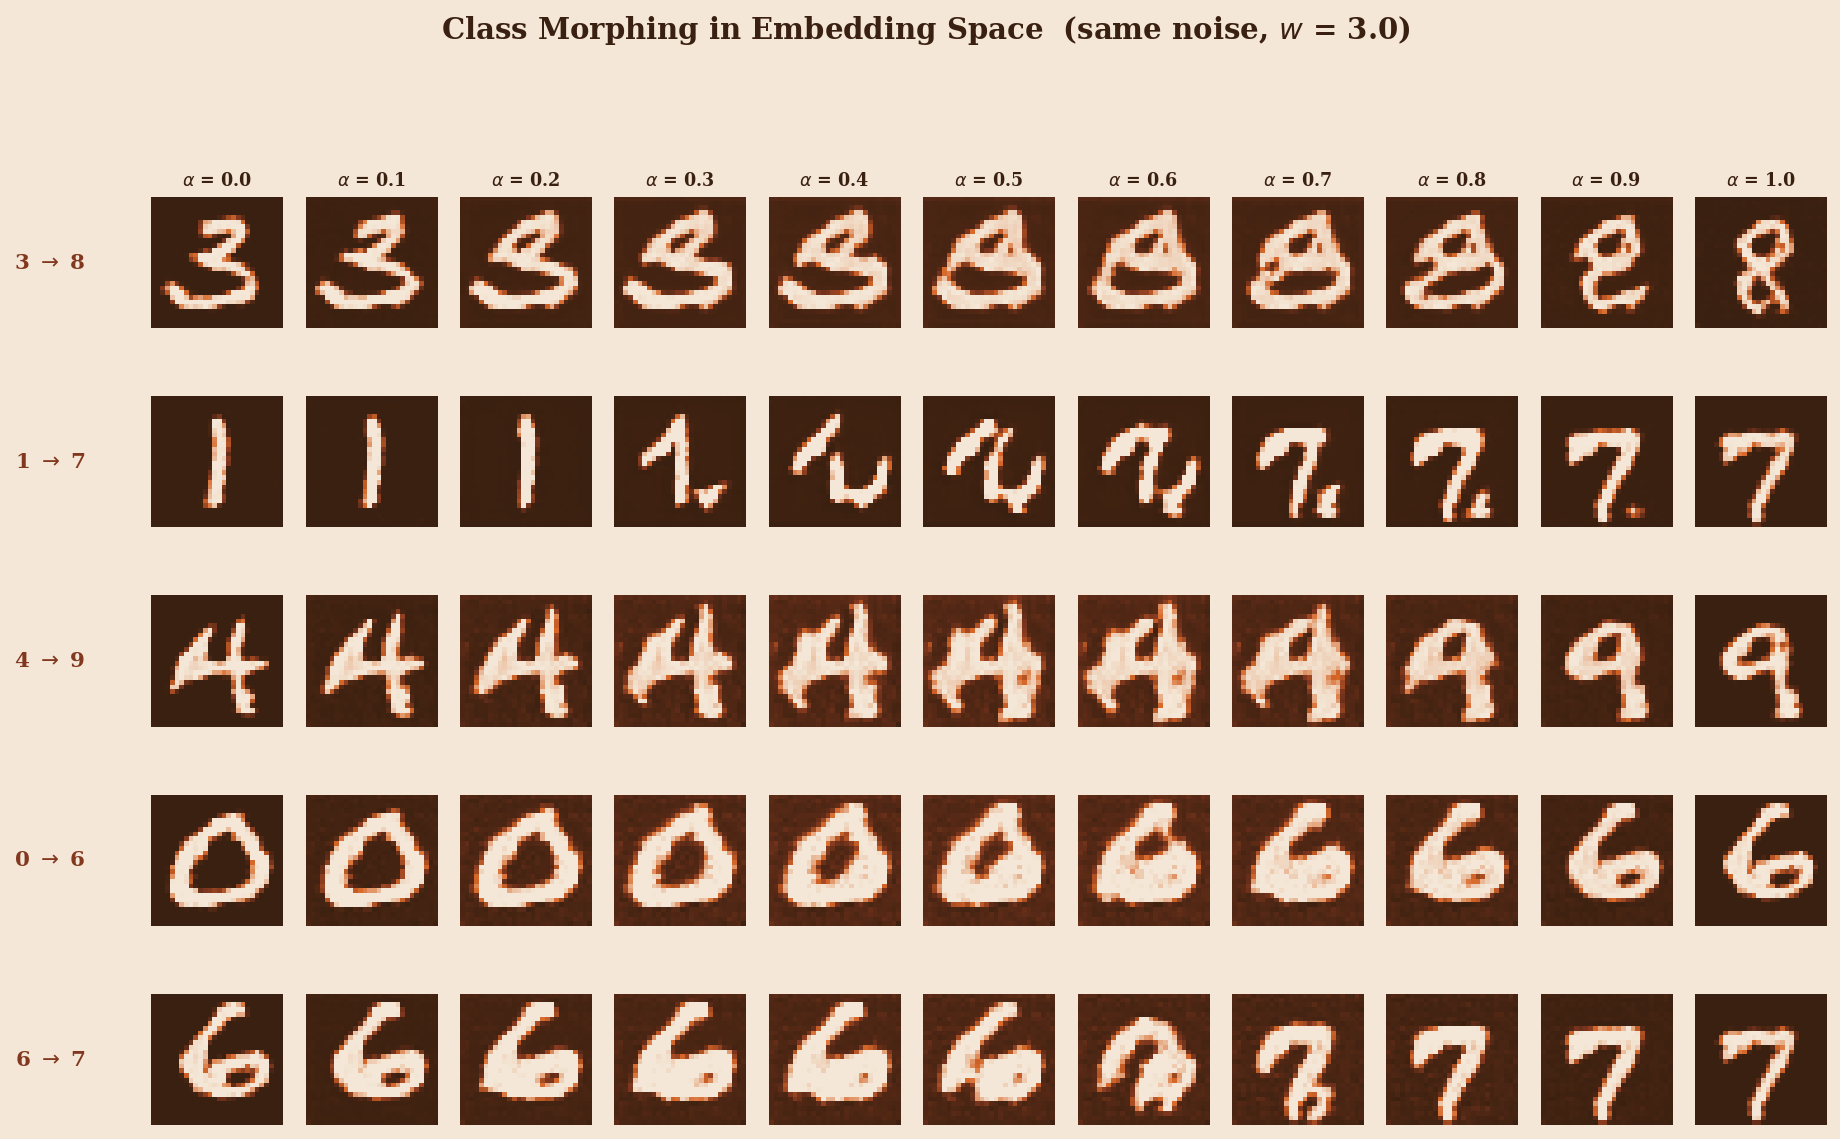

In [ ]:
morph_pairs = [(3, 8), (1, 7), (4, 9), (0, 6), (6,7)]
n_morph = 11
alphas_morph = torch.linspace(0, 1, n_morph)

torch.manual_seed(42)
z_morph = torch.randn(1, 1, 28, 28, device=device)

fig, axes = plt.subplots(len(morph_pairs), n_morph,
                         figsize=(n_morph * 1.2, len(morph_pairs) * 1.6))
fig.patch.set_facecolor(BG_COLOR)

for row, (ca, cb) in enumerate(morph_pairs):
    for col, alpha in enumerate(alphas_morph):
        img = sample_class_morph(model, z_morph, ca, cb, alpha.item(),
                                guidance_scale=3.0)
        axes[row, col].imshow(img[0, 0].cpu(), cmap=DIGIT_CMAP, vmin=-1, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"$\\alpha$ = {alpha:.1f}", fontsize=9,
                                     color=TEXT_COLOR)

    axes[row, 0].text(
        -0.5, 0.5, f"{ca} $\\to$ {cb}", transform=axes[row, 0].transAxes,
        fontsize=11, fontweight="bold", color=ACCENT2,
        ha="right", va="center",
    )

fig.suptitle("Class Morphing in Embedding Space  (same noise, $w$ = 3.0)",
             fontsize=15, fontweight="bold", color=TEXT_COLOR, y=1.05)
plt.tight_layout()
plt.show()


## Summary

| Component | Detail |
|---|---|
| **Model** | Small UNet with sinusoidal time + learned class embeddings |
| **Training** | Conditional flow matching with 15% label dropout for CFG |
| **Sampler** | Euler method, `ODE_STEPS` steps (configurable) |
| **Guidance** | CFG with scale $w$, the higher $w$ sharpens samples but reduces diversity |
| **Inpainting** | Replacement method: constrain known pixels to their interpolation path during ODE solve |
| **Class morphing** | Interpolate class embeddings to smoothly blend between digit identities |

**Key takeaways:**
- Flow matching provides a simple, simulation-free training objective
- Linear interpolation paths $x_t = (1-t)x_0 + tx_1$ make implementation straightforward
- Classifier-free guidance gives controllable generation quality without a separate classifier
- The guidance scale $w$ provides a direct quality--diversity knob
- Even 5 Euler steps can produce high quality digits
- The learned velocity field can be repurposed for **inpainting** via the replacement method, with no retraining needed